In [1]:
import os
import zipfile
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Find the uploaded ZIP file
zip_files = glob.glob('/content/*.zip')

print("Uploaded ZIP file:", zip_files)

# Extract the ZIP file
with zipfile.ZipFile(zip_files[0], 'r') as zip_ref:
    zip_ref.extractall('/content/titanic_data')

# Find CSV files
csv_files = glob.glob('/content/titanic_data/**/*.csv', recursive=True)

print("\nCSV files found:")
for file in csv_files:
    print(file)

Uploaded ZIP file: ['/content/archive.zip']

CSV files found:
/content/titanic_data/SVMtrain.csv


In [2]:
# Load the Titanic dataset
df = pd.read_csv('/content/titanic_data/SVMtrain.csv')

# Display the first 5 rows
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,Male,22.0,1,0,7.2500,3
1,2,1,1,female,38.0,1,0,71.2833,1
2,3,1,3,female,26.0,0,0,7.9250,3
3,4,1,1,female,35.0,1,0,53.1000,3
4,5,0,3,Male,35.0,0,0,8.0500,3


In [3]:
# Check the dataset shape
print("Dataset Shape:", df.shape)

# Display column names
print("\nColumn Names:")
print(df.columns.tolist())

# Display dataset information
print("\nDataset Information:")
df.info()

Dataset Shape: (889, 9)

Column Names:
['PassengerId', 'Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 889 entries, 0 to 888
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    int64  
 2   Pclass       889 non-null    int64  
 3   Sex          889 non-null    object 
 4   Age          889 non-null    float64
 5   SibSp        889 non-null    int64  
 6   Parch        889 non-null    int64  
 7   Fare         889 non-null    float64
 8   Embarked     889 non-null    int64  
dtypes: float64(2), int64(6), object(1)
memory usage: 62.6+ KB


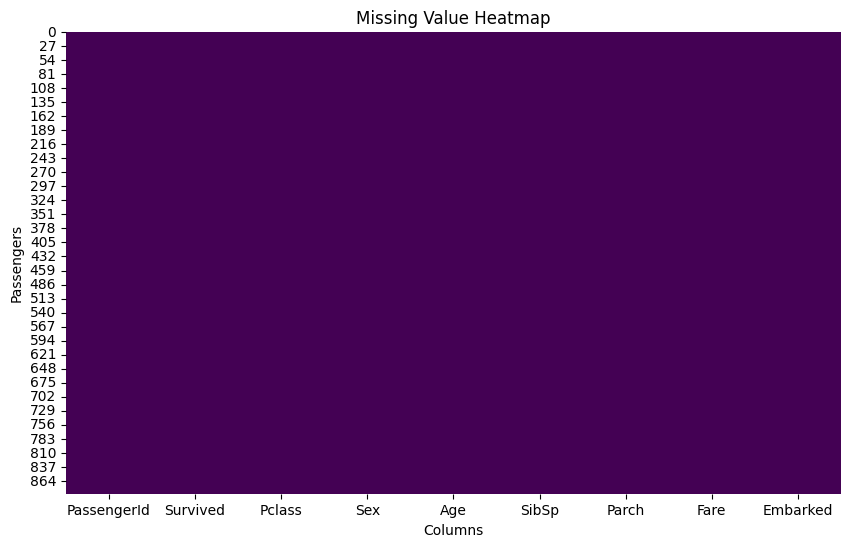

In [4]:
# Missing-value heatmap

plt.figure(figsize=(10, 6))

sns.heatmap(df.isnull(), cbar=False, cmap="viridis")

plt.title("Missing Value Heatmap")
plt.xlabel("Columns")
plt.ylabel("Passengers")

plt.show()

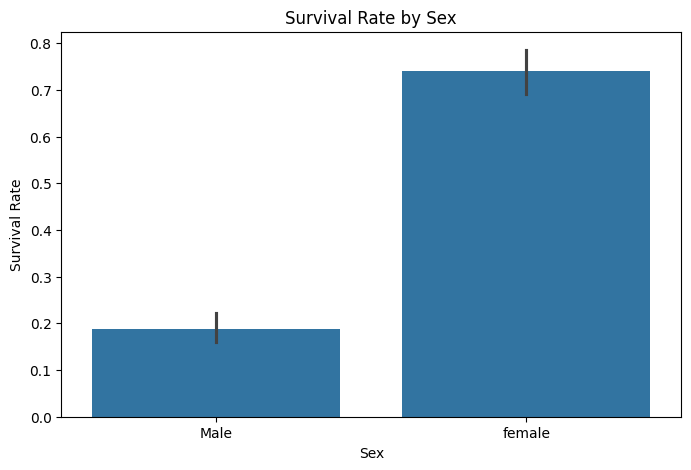

In [5]:
# Survival analysis by Sex

plt.figure(figsize=(8, 5))

sns.barplot(data=df, x="Sex", y="Survived")

plt.title("Survival Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Survival Rate")

plt.show()

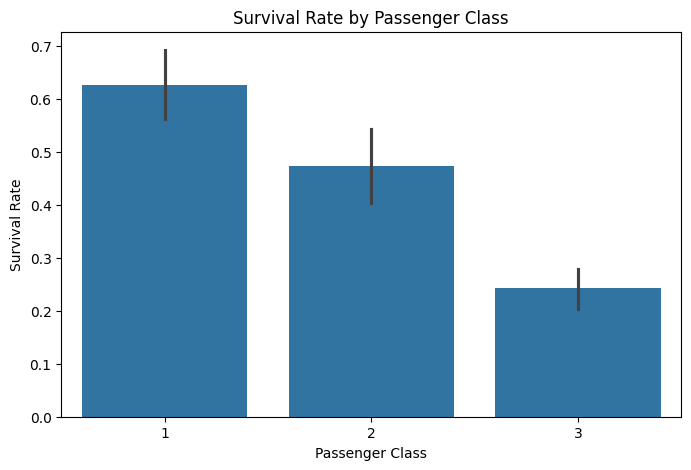

In [6]:
# Survival analysis by Passenger Class

plt.figure(figsize=(8, 5))

sns.barplot(data=df, x="Pclass", y="Survived")

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

plt.show()

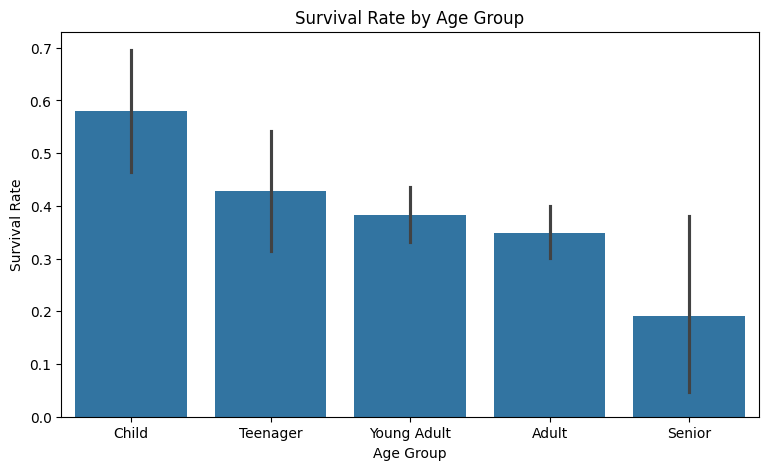

In [7]:
# Create age groups
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 12, 18, 35, 60, 100],
    labels=["Child", "Teenager", "Young Adult", "Adult", "Senior"]
)

# Survival analysis by Age Group
plt.figure(figsize=(9, 5))

sns.barplot(data=df, x="AgeGroup", y="Survived")

plt.title("Survival Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Survival Rate")

plt.show()

In [8]:
# Lifecycle mapping dictionary

lifecycle_mapping = {
    "Child": "Childhood",
    "Teenager": "Adolescence",
    "Young Adult": "Young Adulthood",
    "Adult": "Adulthood",
    "Senior": "Old Age"
}

# Apply lifecycle mapping
df["Lifecycle"] = df["AgeGroup"].map(lifecycle_mapping)

# Display the mapping
print("Lifecycle Mapping Dictionary:")
print(lifecycle_mapping)

# Display sample results
df[["Age", "AgeGroup", "Lifecycle"]].head(10)

Lifecycle Mapping Dictionary:
{'Child': 'Childhood', 'Teenager': 'Adolescence', 'Young Adult': 'Young Adulthood', 'Adult': 'Adulthood', 'Senior': 'Old Age'}


,Age,AgeGroup,Lifecycle
0,22.0,Young Adult,Young Adulthood
1,38.0,Adult,Adulthood
2,26.0,Young Adult,Young Adulthood
3,35.0,Young Adult,Young Adulthood
4,35.0,Young Adult,Young Adulthood
5,60.0,Adult,Adulthood
6,54.0,Adult,Adulthood
7,2.0,Child,Childhood
8,27.0,Young Adult,Young Adulthood
9,14.0,Teenager,Adolescence


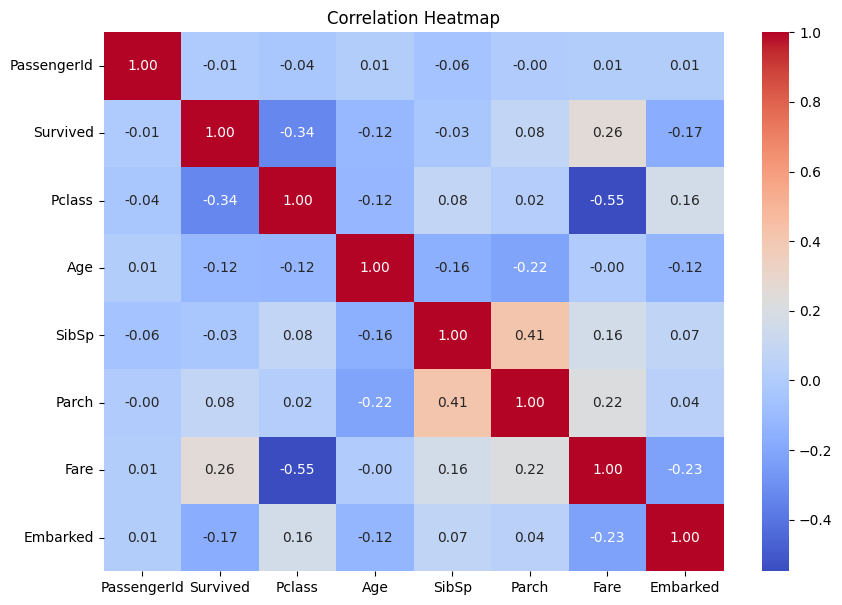

In [9]:
# Correlation heatmap

plt.figure(figsize=(10, 7))

correlation = df.select_dtypes(include="number").corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [10]:
# ============================================================
# EXPORT TITANIC EDA REPORT AS A 4-PAGE PDF
# ============================================================

from matplotlib.backends.backend_pdf import PdfPages

pdf_filename = "titanic_eda_report.pdf"

with PdfPages(pdf_filename) as pdf:

    # --------------------------------------------------------
    # PAGE 1: Dataset Overview + Missing Value Heatmap
    # --------------------------------------------------------
    fig = plt.figure(figsize=(11, 8.5))

    fig.suptitle(
        "Titanic Dataset - Exploratory Data Analysis",
        fontsize=18,
        fontweight="bold"
    )

    ax1 = fig.add_axes([0.08, 0.58, 0.84, 0.30])
    ax1.axis("off")

    overview_text = (
        f"Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns\n\n"
        "Columns:\n"
        + ", ".join(df.columns[:9])
        + "\n\n"
        "Missing Values: None"
    )

    ax1.text(
        0,
        0.9,
        overview_text,
        fontsize=12,
        verticalalignment="top"
    )

    ax2 = fig.add_axes([0.10, 0.08, 0.80, 0.38])

    sns.heatmap(
        df.isnull(),
        cbar=False,
        cmap="viridis",
        ax=ax2
    )

    ax2.set_title("Missing Value Heatmap")
    ax2.set_xlabel("Columns")
    ax2.set_ylabel("Passengers")

    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    # --------------------------------------------------------
    # PAGE 2: Survival Analysis
    # --------------------------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # Survival by Sex
    sns.barplot(
        data=df,
        x="Sex",
        y="Survived",
        ax=axes[0]
    )
    axes[0].set_title("Survival Rate by Sex")
    axes[0].set_xlabel("Sex")
    axes[0].set_ylabel("Survival Rate")

    # Survival by Class
    sns.barplot(
        data=df,
        x="Pclass",
        y="Survived",
        ax=axes[1]
    )
    axes[1].set_title("Survival Rate by Passenger Class")
    axes[1].set_xlabel("Passenger Class")
    axes[1].set_ylabel("Survival Rate")

    # Survival by Age Group
    sns.barplot(
        data=df,
        x="AgeGroup",
        y="Survived",
        ax=axes[2]
    )
    axes[2].set_title("Survival Rate by Age Group")
    axes[2].set_xlabel("Age Group")
    axes[2].set_ylabel("Survival Rate")

    fig.suptitle(
        "Titanic Survival Analysis",
        fontsize=18,
        fontweight="bold"
    )

    plt.tight_layout(rect=[0, 0, 1, 0.92])

    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    # --------------------------------------------------------
    # PAGE 3: Lifecycle Mapping
    # --------------------------------------------------------
    fig = plt.figure(figsize=(11, 8.5))

    fig.suptitle(
        "Lifecycle Mapping",
        fontsize=18,
        fontweight="bold"
    )

    ax = fig.add_axes([0.10, 0.15, 0.80, 0.70])
    ax.axis("off")

    mapping_text = "Age Group → Lifecycle Stage\n\n"

    for age_group, lifecycle in lifecycle_mapping.items():
        mapping_text += f"{age_group} → {lifecycle}\n"

    ax.text(
        0.5,
        0.5,
        mapping_text,
        fontsize=16,
        ha="center",
        va="center"
    )

    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    # --------------------------------------------------------
    # PAGE 4: Correlation Heatmap
    # --------------------------------------------------------
    fig = plt.figure(figsize=(11, 8.5))

    ax = fig.add_axes([0.10, 0.12, 0.80, 0.75])

    correlation = df.select_dtypes(include="number").corr()

    sns.heatmap(
        correlation,
        annot=True,
        cmap="coolwarm",
        fmt=".2f",
        ax=ax
    )

    ax.set_title(
        "Correlation Heatmap",
        fontsize=16,
        fontweight="bold"
    )

    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

print(f"PDF created successfully: {pdf_filename}")

PDF created successfully: titanic_eda_report.pdf
